# Whole-brain projection — focused three-motif map

Week of 31 Aug–4 Sep 2026: this is the only locked figure from the
whole-brain projection work. Extra-insula electrodes are projected onto the
frozen insula concat-NMF templates (sensory / sustain / motor). The map is
**waveform similarity**, not connectivity.

**Figure:** `img/nmf/whole_brain_projection/wholebrain_surface_motifs_focused_combined_pial_top50.svg`

**Code path**

- Compute: `src/nmf/whole_brain_projection.py` (`sbatch scripts/slurm/nmf_whole_brain_projection.sh`)
- Surface cache / library plot: `src/nmf/whole_brain_projection_viz.py`, `scripts/plot_nmf_whole_brain_projection.py`
- This notebook: pial 2×2 from `surface_motif_maps_focused.npz`

See `docs/NMF.md` §7.


In [9]:
%matplotlib inline

from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.nmf.waveform_analysis as waveform_analysis
import src.nmf.whole_brain_projection_viz as whole_brain_projection_viz

importlib.reload(waveform_analysis)
importlib.reload(whole_brain_projection_viz)

from src.nmf.waveform_analysis import CLUSTER_LABELS, CLUSTER_ORDER, FUNCTION_COLORS
from src.nmf.whole_brain_projection_viz import (
    combined_focused_rgba,
    offset_vertices_along_normals,
    retain_largest_surface_clusters,
    surface_label_boundary_edges,
)
from src.paths import img_dir, nmf_wholebrain_dir, save_svg


In [10]:
cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"

RECON_DIR = Path("/cwork/ns458/ECoG_Recon")
TEMPLATE_SUBJECT = "cvs_avg35_inMNI152"
COMPONENTS = tuple(CLUSTER_ORDER)
COMPONENT_LABELS = dict(CLUSTER_LABELS)
LANDMARK_ROIS = (
    ("HG", "transversetemporal", "#111111"),
    ("STG", "superiortemporal", "#1B4332"),
    ("PrG", "precentral", "#1D3557"),
    ("PoG", "postcentral", "#6B3F2A"),
    ("Insula", "insula", "#4A4A4A"),
)
OVERLAY_NORMAL_OFFSET_MM = 0.5
OUTLINE_NORMAL_OFFSET_MM = 0.7
KEEP_TOP = 0.50
FOCUSED_MIN_SUBJECTS = 3
FOCUSED_POSITIVE_FRACTION = 0.50
FOCUSED_MAX_CLUSTERS = 5
FOCUSED_MIN_CLUSTER_VERTICES = 20

CACHE = nmf_wholebrain_dir() / "visualization" / "surface_motif_maps_focused.npz"
FIG_DIR = img_dir("nmf/whole_brain_projection")
PIAL = (
    FIG_DIR
    / f"wholebrain_surface_motifs_focused_combined_pial_top{int(round(KEEP_TOP * 100))}.svg"
)
APARC_SVG = FIG_DIR / "wholebrain_surface_motifs_focused_aparc_share.svg"

print("cache", CACHE)
print("out", PIAL)
print("aparc", APARC_SVG)
print("FUNCTION_COLORS", FUNCTION_COLORS)


cache /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/whole_brain_projection/visualization/surface_motif_maps_focused.npz
out /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/wholebrain_surface_motifs_focused_combined_pial_top50.svg
aparc /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/wholebrain_surface_motifs_focused_aparc_share.svg
FUNCTION_COLORS {'sustain': '#C4A35A', 'motor': '#A9373B', 'sensory': '#2369BD'}


In [11]:
def add_rgba_overlay(brain, hemi: str, rgba: np.ndarray) -> None:
    import pyvista as pv

    coords = np.asarray(brain.geo[hemi].coords, dtype=float)
    faces = np.asarray(brain.geo[hemi].faces, dtype=np.int64)
    if len(coords) != len(rgba):
        raise ValueError(
            f"{hemi} overlay length {len(rgba)} does not match mesh {len(coords)}"
        )
    visible = np.asarray(rgba[:, 3], dtype=float) > 1e-6
    keep = visible[faces].any(axis=1)
    if not keep.any():
        return
    lifted = offset_vertices_along_normals(coords, faces, OVERLAY_NORMAL_OFFSET_MM)
    cells = np.hstack(
        [np.full((int(keep.sum()), 1), 3, dtype=np.int64), faces[keep]]
    ).ravel()
    mesh = pv.PolyData(lifted, cells)
    mesh["rgba"] = (np.clip(rgba, 0.0, 1.0) * 255.0).astype(np.uint8)
    brain._renderer.plotter.add_mesh(
        mesh,
        scalars="rgba",
        rgba=True,
        lighting=False,
        smooth_shading=True,
    )


def aparc_label_map(hemi: str) -> dict[str, object]:
    import mne

    labels = mne.read_labels_from_annot(
        TEMPLATE_SUBJECT,
        parc="aparc",
        subjects_dir=str(RECON_DIR),
        hemi=hemi,
    )
    return {label.name.rsplit("-", 1)[0]: label for label in labels}


def add_landmark_outlines(brain, hemi: str) -> None:
    import pyvista as pv

    coords = np.asarray(brain.geo[hemi].coords, dtype=float)
    faces = np.asarray(brain.geo[hemi].faces, dtype=np.int64)
    lifted = offset_vertices_along_normals(coords, faces, OUTLINE_NORMAL_OFFSET_MM)
    labels = aparc_label_map(hemi)
    for _, aparc_name, color in LANDMARK_ROIS:
        label = labels.get(aparc_name)
        if label is None:
            continue
        mask = np.zeros(len(coords), dtype=bool)
        vertices = np.asarray(label.vertices, dtype=int)
        valid = (vertices >= 0) & (vertices < len(coords))
        mask[vertices[valid]] = True
        edges = surface_label_boundary_edges(faces, mask)
        if len(edges) == 0:
            continue
        cells = np.empty(len(edges) * 3, dtype=np.int64)
        cells[0::3] = 2
        cells[1::3] = edges[:, 0]
        cells[2::3] = edges[:, 1]
        mesh = pv.PolyData()
        mesh.points = lifted
        mesh.lines = cells
        brain._renderer.plotter.add_mesh(
            mesh,
            color=color,
            line_width=2.4,
            lighting=False,
            render_lines_as_tubes=False,
        )


def render_hemisphere(payload, hemi, thresholds, value_max, surf="pial"):
    import mne
    from mne.viz import Brain

    brain = Brain(
        TEMPLATE_SUBJECT,
        subjects_dir=str(RECON_DIR),
        surf=surf,
        hemi=hemi,
        background="white",
        show=False,
        cortex=(0.88, 0.88, 0.88),
        alpha=1.0,
        size=(550, 450),
    )
    add_rgba_overlay(
        brain,
        hemi,
        combined_focused_rgba(payload, hemi, thresholds, value_max),
    )
    add_landmark_outlines(brain, hemi)
    distance = 450.0 if surf == "pial" else 550.0
    images = {}
    for view in ("lateral", "medial"):
        brain.show_view(view=view, distance=distance)
        images[view] = brain.screenshot(mode="rgb")
    brain.close()
    return images


CORTEX_GRAY = np.array([0.88, 0.88, 0.88])


def overlay_colormap(hex_color, n: int = 256):
    """Match combined_focused_rgba: hue over gray cortex, alpha 0.40→1."""
    import matplotlib.colors as mcolors

    rgb = np.asarray(mcolors.to_rgb(hex_color), dtype=float)
    fraction = np.linspace(0.0, 1.0, n)
    intensity = 0.40 + 0.60 * fraction
    colors = intensity[:, None] * rgb[None, :] + (1.0 - intensity)[:, None] * CORTEX_GRAY
    return mcolors.LinearSegmentedColormap.from_list("motif_overlay", colors)


def refocus_payload(payload, keep_top: float = KEEP_TOP):
    """Rebuild display masks from the cached maps at a new keep-top fraction."""
    import mne

    if not 0.0 < keep_top <= 1.0:
        raise ValueError("keep_top must be in (0, 1]")
    surface_quantile = 1.0 - keep_top
    faces_by_hemi = {}
    for hemi in ("lh", "rh"):
        _, faces = mne.read_surface(
            str(RECON_DIR / TEMPLATE_SUBJECT / "surf" / f"{hemi}.pial")
        )
        faces_by_hemi[hemi] = faces

    thresholds = {}
    for component in COMPONENTS:
        eligible_parts = []
        for hemi in ("lh", "rh"):
            data = np.asarray(payload[f"{hemi}_{component}_specificity"], dtype=float)
            coverage = np.asarray(payload[f"{hemi}_{component}_coverage"])
            positive_fraction = np.asarray(
                payload[f"{hemi}_{component}_positive_fraction"]
            )
            eligible = (
                (coverage >= FOCUSED_MIN_SUBJECTS)
                & (positive_fraction >= FOCUSED_POSITIVE_FRACTION)
                & np.isfinite(data)
                & (data > 0)
            )
            eligible_parts.append(data[eligible])
        combined = np.concatenate(eligible_parts)
        thresholds[component] = (
            float(np.quantile(combined, surface_quantile)) if len(combined) else np.inf
        )
        for hemi in ("lh", "rh"):
            data = np.asarray(payload[f"{hemi}_{component}_specificity"], dtype=float)
            coverage = np.asarray(payload[f"{hemi}_{component}_coverage"])
            positive_fraction = np.asarray(
                payload[f"{hemi}_{component}_positive_fraction"]
            )
            candidate = (
                (coverage >= FOCUSED_MIN_SUBJECTS)
                & (positive_fraction >= FOCUSED_POSITIVE_FRACTION)
                & np.isfinite(data)
                & (data >= thresholds[component])
            )
            payload[f"{hemi}_{component}_display_mask"] = retain_largest_surface_clusters(
                candidate,
                faces_by_hemi[hemi],
                max_clusters=FOCUSED_MAX_CLUSTERS,
                min_vertices=FOCUSED_MIN_CLUSTER_VERTICES,
            )
    payload["display_thresholds"] = np.array(
        [thresholds[name] for name in COMPONENTS]
    )
    return payload, thresholds


def add_specificity_colorbar(fig, vmin: float, vmax: float) -> None:
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    axis = fig.add_axes([0.28, 0.155, 0.44, 0.028])
    cmap = overlay_colormap("#222222")
    norm = mcolors.Normalize(vmin=vmin, vmax=max(vmax, vmin + 1e-6))
    handle = cm.ScalarMappable(norm=norm, cmap=cmap)
    handle.set_array([])
    colorbar = fig.colorbar(handle, cax=axis, orientation="horizontal")
    colorbar.set_ticks([vmin, vmax])
    colorbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
    colorbar.set_label("specificity", fontsize=7, labelpad=2)
    colorbar.ax.tick_params(labelsize=6, width=0.6, length=2)
    colorbar.outline.set_linewidth(0.6)



## Focused territories on pial


Reading labels from parcellation...
   read 34 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.annot
Reading labels from parcellation...
   read 34 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.annot
keep top 50% of eligible vertices
per-motif floors: {'sustained': '0.114', 'motor': '0.162', 'sensory': '0.099'}
colorbar 0.099 → 0.471
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/wholebrain_surface_motifs_focused_combined_pial_top50.svg


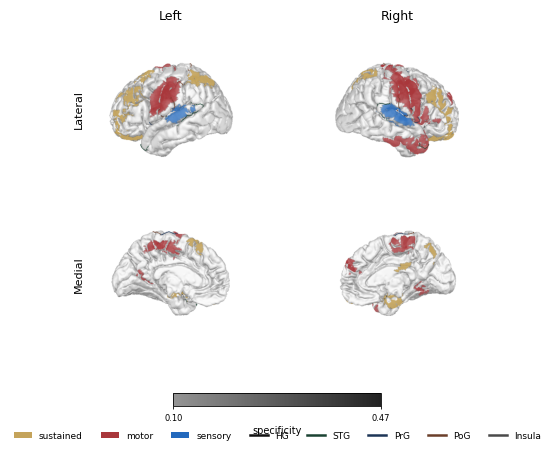

In [12]:
import mne

if not CACHE.exists():
    raise FileNotFoundError(CACHE)

with np.load(CACHE) as raw:
    payload = {key: raw[key] for key in raw.files}
payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)
value_max = float(np.asarray(payload["display_value_max"]).reshape(-1)[0])
vmin = float(np.min([thresholds[name] for name in COMPONENTS]))

mne.viz.set_3d_backend("notebook")
views = (("lateral", "Lateral"), ("medial", "Medial"))
hemis = (("lh", "Left"), ("rh", "Right"))
screenshots = {
    hemi: render_hemisphere(payload, hemi, thresholds, value_max, surf="pial")
    for hemi, _ in hemis
}

fig, axes = plt.subplots(2, 2, figsize=(12.0 * cm, 12.4 * cm))
for row, (view, view_label) in enumerate(views):
    for column, (hemi, hemi_label) in enumerate(hemis):
        axes[row, column].imshow(screenshots[hemi][view])
        axes[row, column].axis("off")
        if row == 0:
            axes[row, column].set_title(hemi_label, fontsize=9)
        if column == 0:
            axes[row, column].text(
                0.01,
                0.5,
                view_label,
                transform=axes[row, column].transAxes,
                rotation=90,
                va="center",
                fontsize=8,
            )

fig.subplots_adjust(
    left=0.04, right=0.99, top=0.93, bottom=0.26, wspace=0.02, hspace=0.02
)
add_specificity_colorbar(fig, vmin, value_max)
fig.legend(
    handles=[
        *(
            Patch(facecolor=FUNCTION_COLORS[name], label=CLUSTER_LABELS[name])
            for name in COMPONENTS
        ),
        *(
            Line2D([0], [0], color=color, lw=1.8, label=name)
            for name, _, color in LANDMARK_ROIS
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.12),
    ncol=8,
    frameon=False,
    fontsize=6.5,
)

print(f"keep top {KEEP_TOP:.0%} of eligible vertices")
print(
    "per-motif floors:",
    {CLUSTER_LABELS[name]: f"{thresholds[name]:.3f}" for name in COMPONENTS},
)
print(f"colorbar {vmin:.3f} → {value_max:.3f}")
save_svg(fig, PIAL, close=False)
print(f"Wrote {PIAL}")
plt.show()

## What each color sits on

Count held-out electrodes whose nearest pial vertex falls in the same
winner-take-all patches as the brain. Bars are raw electrode counts in
Hammers ROIs; insula (AIC/PIC) omitted; top four ROIs per motif.



Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/wholebrain_surface_motifs_focused_aparc_share.svg
in patch (no insula): 1328 electrodes
sensory: STGp 211, pTL 62, SMG 18, SPL 3, others 0
sustained: MFG 212, OFC 161, SFG 36, Amyg 33, others 124
motor: PrG 183, PoG 113, SMG 36, TP 22, others 114


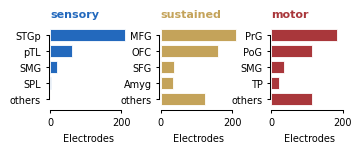

In [13]:
import pandas as pd
import seaborn as sns

from src.nmf.oaec_focused_overlay import assign_focused_membership, focused_mask_payload
from src.nmf.whole_brain_projection_viz import prepare_projection_frame
from src.paths import nmf_wholebrain_dir

APARC_SVG = FIG_DIR / "wholebrain_surface_motifs_focused_aparc_share.svg"
INSULA_ROIS = {"AIC", "PIC", "Insula", "insula"}
MAX_DISTANCE_MM = 15.0
TOP_N = 4
PLOT_ORDER = ("sensory", "sustain", "motor")


if "payload" not in globals():
    if not CACHE.exists():
        raise FileNotFoundError(CACHE)
    with np.load(CACHE) as raw:
        payload = {key: raw[key] for key in raw.files}
    payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)

import mne

vertices_by_hemi = {}
for hemi in ("lh", "rh"):
    vertices, _ = mne.read_surface(
        str(RECON_DIR / TEMPLATE_SUBJECT / "surf" / f"{hemi}.pial")
    )
    vertices_by_hemi[hemi] = vertices

electrodes = prepare_projection_frame(
    pd.read_csv(nmf_wholebrain_dir() / "electrode_projection.csv")
)
mask_by_hemi, specificity_by_hemi = focused_mask_payload(
    payload, components=COMPONENTS
)
marked = assign_focused_membership(
    electrodes,
    vertices_by_hemi=vertices_by_hemi,
    mask_by_hemi=mask_by_hemi,
    specificity_by_hemi=specificity_by_hemi,
    components=COMPONENTS,
    max_distance=MAX_DISTANCE_MM,
)
in_patch = marked.loc[
    marked["in_focused"].eq(True)
    & marked["focused_component"].notna()
    & ~marked["roi"].astype(str).isin(INSULA_ROIS)
].copy()
counts = (
    in_patch.groupby(["focused_component", "roi"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
keep = []
for component in PLOT_ORDER:
    subset = counts.loc[counts["focused_component"].eq(component)].sort_values(
        "n", ascending=False
    )
    top = subset.head(TOP_N).copy()
    rest = subset.iloc[TOP_N:]
    other_n = int(rest["n"].sum()) if len(rest) else 0
    top = pd.concat(
        [
            top,
            pd.DataFrame(
                {
                    "focused_component": [component],
                    "roi": ["others"],
                    "n": [other_n],
                }
            ),
        ],
        ignore_index=True,
    )
    keep.append(top)
plot_frame = pd.concat(keep, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(9.0 * cm, 3 * cm), sharex=False)
xmax = max(10, int(plot_frame["n"].max()) + 2)
for ax, component in zip(axes, PLOT_ORDER):
    subset = plot_frame.loc[plot_frame["focused_component"].eq(component)].iloc[::-1]
    ax.barh(
        subset["roi"],
        subset["n"],
        color=FUNCTION_COLORS[component],
        height=0.72,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title(
        CLUSTER_LABELS[component],
        color=FUNCTION_COLORS[component],
        fontsize=8,
        fontweight="bold",
        loc="left",
    )
    ax.set_xlim(0, xmax)
    ax.tick_params(labelsize=7, width=0.75, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    ax.set_xlabel("Electrodes", fontsize=7)
fig.subplots_adjust(left=0.14, right=0.98, top=0.88, bottom=0.18, wspace=0.45)
save_svg(fig, APARC_SVG, close=False)
print(f"Wrote {APARC_SVG}")
print(f"in patch (no insula): {len(in_patch)} electrodes")
for component in PLOT_ORDER:
    subset = plot_frame.loc[plot_frame["focused_component"].eq(component)]
    summary = ", ".join(f"{row.roi} {int(row.n)}" for row in subset.itertuples())
    print(f"{CLUSTER_LABELS[component]}: {summary}")
plt.show()

## OAEC among these territories

Subject-level pair hit-rate: insula NMF cluster × extra-insula partner motif.
Partners are restricted to the same focused patches as the pial map
(`KEEP_TOP`). OAEC is undirected; this is trial-wise envelope co-fluctuation
inside a motif-matched partner pool, not evidence that insula owns three
whole-brain networks.

Loading all pair tables is heavy. Default is to plot from the Slurm CSV.
Set `RECOMPUTE_OAEC = True` only on a compute node if you changed `KEEP_TOP`.


loaded /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/whole_brain_projection/visualization/oaec_motif_coupling_group.csv
source_cluster partner_component  n_subjects  n_pairs  n_sig_pairs  mean_pair_hit  median_pair_hit   mean_z  within_motif
       sustain           sustain          17      149           45       0.283310         0.208333 0.196408          True
       sustain             motor          15      119           29       0.297835         0.200000 0.148985         False
       sustain           sensory          15       98           12       0.139709         0.111111 0.128854         False
         motor           sustain          30      349           85       0.177235         0.166667 0.168531         False
         motor             motor          29      370          101       0.287946         0.266667 0.158629          True
         motor           sensory          26      270           84       0.260511         0.225000 0.174809         False
       senso

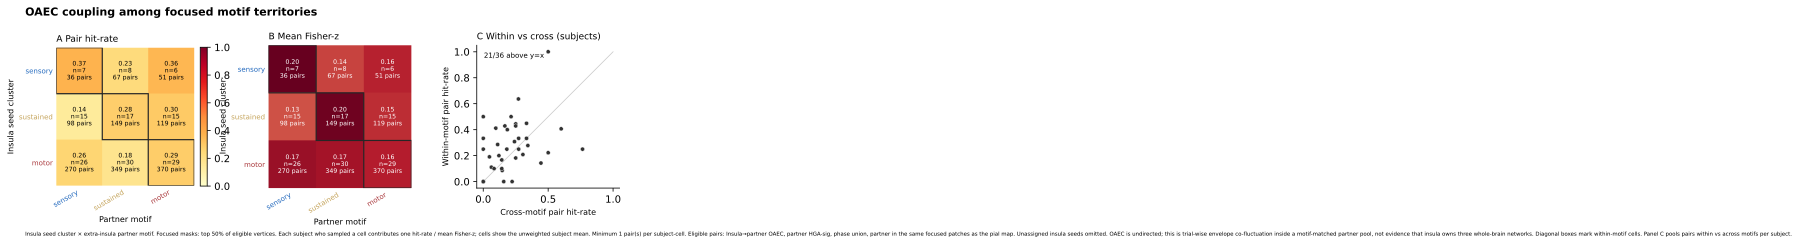

In [14]:
import importlib.util

import pandas as pd
from IPython.display import SVG, display

from src.nmf.oaec_focused_overlay import (
    annotate_motif_pairs,
    assign_focused_membership,
    focused_mask_payload,
    group_motif_coupling,
    mark_partner_significance,
    select_overlay_electrodes,
    subject_motif_coupling,
    subject_within_cross,
)

PLOT_ORDER = ("sensory", "sustain", "motor")
RECOMPUTE_OAEC = False
MIN_PAIRS = 1
MAX_DISTANCE_MM = 15.0
COUPLING_DIR = nmf_wholebrain_dir() / "visualization"
COUPLING_SVG = FIG_DIR / "oaec_motif_coupling_3x3.svg"
COUPLING_GROUP = COUPLING_DIR / "oaec_motif_coupling_group.csv"
COUPLING_CONTRAST = COUPLING_DIR / "oaec_motif_coupling_within_cross.csv"
OVERLAY_CSV = COUPLING_DIR / "oaec_overlay_electrodes_incluster.csv"


def _load_script(name: str, relative: str):
    path = ROOT / relative
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise ImportError(path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


coupling_plot = _load_script(
    "plot_oaec_motif_coupling", "scripts/plot_oaec_motif_coupling.py"
)

if "payload" not in globals():
    if not CACHE.exists():
        raise FileNotFoundError(CACHE)
    with np.load(CACHE) as raw:
        payload = {key: raw[key] for key in raw.files}
    payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)

if RECOMPUTE_OAEC:
    plot_oaec = _load_script(
        "plot_oaec_pooled_subject_lh", "scripts/plot_oaec_pooled_subject_lh.py"
    )
    if "vertices_by_hemi" not in globals():
        import mne

        vertices_by_hemi = {}
        for hemi in ("lh", "rh"):
            vertices, _ = mne.read_surface(
                str(RECON_DIR / TEMPLATE_SUBJECT / "surf" / f"{hemi}.pial")
            )
            vertices_by_hemi[hemi] = vertices
    mask_by_hemi, specificity_by_hemi = focused_mask_payload(
        payload, components=COMPONENTS
    )
    channel_meta, _exclude = plot_oaec.load_channel_meta()
    raw_pairs = plot_oaec.load_metric_repeat("oaec")
    pairs = plot_oaec.annotate_within_pair(
        raw_pairs,
        channel_meta,
        partner_hga_sig=True,
        sig_only=False,
    )
    projection = pd.read_csv(nmf_wholebrain_dir() / "electrode_projection.csv")
    overlay_electrodes = select_overlay_electrodes(pairs, channel_meta, projection)
    overlay_electrodes = assign_focused_membership(
        overlay_electrodes,
        vertices_by_hemi=vertices_by_hemi,
        mask_by_hemi=mask_by_hemi,
        specificity_by_hemi=specificity_by_hemi,
        max_distance=MAX_DISTANCE_MM,
    )
    overlay_electrodes = mark_partner_significance(pairs, overlay_electrodes)
    labeled = annotate_motif_pairs(pairs, overlay_electrodes, projection)
    cells = subject_motif_coupling(labeled, min_pairs=MIN_PAIRS)
    group = group_motif_coupling(cells)
    contrast = subject_within_cross(labeled)
    COUPLING_DIR.mkdir(parents=True, exist_ok=True)
    overlay_electrodes.to_csv(OVERLAY_CSV, index=False)
    cells.to_csv(COUPLING_DIR / "oaec_motif_coupling_subject.csv", index=False)
    group.to_csv(COUPLING_GROUP, index=False)
    contrast.to_csv(COUPLING_CONTRAST, index=False)
    print(f"recomputed from current KEEP_TOP={KEEP_TOP:.0%}")
    print(group.to_string(index=False))
else:
    if not COUPLING_GROUP.exists() or not COUPLING_CONTRAST.exists():
        raise FileNotFoundError(
            "Coupling CSVs not found. Submit "
            "scripts/slurm/oaec_motif_coupling.sh or set RECOMPUTE_OAEC = True."
        )
    group = pd.read_csv(COUPLING_GROUP)
    contrast = pd.read_csv(COUPLING_CONTRAST)
    print(f"loaded {COUPLING_GROUP}")
    print(group.to_string(index=False))

written = coupling_plot.plot_coupling(
    group,
    contrast,
    COUPLING_SVG,
    min_pairs=MIN_PAIRS,
    order=PLOT_ORDER,
    keep_top=KEEP_TOP,
)
print(f"Wrote {written}")
display(SVG(filename=str(written)))


## Optional: electrodes on inflated cortex

Same focused masks as the pial map, rendered inflated. Extra-insula partners
in the territories only; insula seeds are not drawn. Colored = significant
OAEC; gray = HGA-sig partner with no significant pair. The 3×3 above is the
main number.


insula_cluster among focused partners: {'motor': 372, 'sustain': 163, nan: 139, 'sensory': 41}
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/wholebrain_surface_motifs_focused_combined_inflated_top50_oaec.svg
surf=inflated focused partners=715 sig=417 never-sig=298


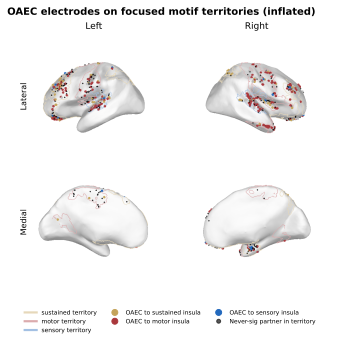

In [15]:
RENDER_OAEC = True
SURF = "inflated"
TERRITORY_ALPHA = 0.40
OAEC_SVG = (
    FIG_DIR
    / f"wholebrain_surface_motifs_focused_combined_{SURF}_top{int(round(KEEP_TOP * 100))}_oaec.svg"
)
OVERLAY_CSV = nmf_wholebrain_dir() / "visualization" / "oaec_overlay_electrodes_incluster.csv"

if not RENDER_OAEC:
    print("skip overlay; set RENDER_OAEC = True to render")
else:
    import importlib
    import src.nmf.oaec_focused_overlay as oaec_focused_overlay

    importlib.reload(oaec_focused_overlay)
    overlay_mod = _load_script(
        "plot_oaec_on_focused_motifs", "scripts/plot_oaec_on_focused_motifs.py"
    )
    nmf_plot = _load_script(
        "plot_nmf_whole_brain_projection",
        "scripts/plot_nmf_whole_brain_projection.py",
    )
    if not OVERLAY_CSV.exists():
        raise FileNotFoundError(OVERLAY_CSV)
    overlay_electrodes = pd.read_csv(OVERLAY_CSV)
    if "thresholds" not in globals() or "value_max" not in globals():
        payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)
        value_max = float(np.asarray(payload["display_value_max"]).reshape(-1)[0])
    if "insula_cluster" not in overlay_electrodes.columns:
        raise KeyError(
            "overlay CSV needs insula_cluster. Wait for scripts/slurm/oaec_motif_coupling.sh "
            "to finish, then re-run this cell."
        )
    plot_frame = overlay_electrodes.loc[
        overlay_electrodes["role"].eq("partner")
        & overlay_electrodes["in_focused"].eq(True)
    ].copy()
    print(
        "insula_cluster among focused partners:",
        plot_frame["insula_cluster"].value_counts(dropna=False).to_dict(),
    )
    n_partner = int(plot_frame["role"].eq("partner").sum())
    if "has_sig" in plot_frame.columns:
        n_sig = int(
            (
                plot_frame["role"].eq("partner")
                & plot_frame["has_sig"].astype(bool)
            ).sum()
        )
        n_gray = n_partner - n_sig
    else:
        n_sig = n_partner
        n_gray = 0
    subtitle = (
        ""
    )
    written = overlay_mod.plot_overlay(
        payload=payload,
        thresholds=thresholds,
        value_max=value_max,
        electrodes=plot_frame,
        output=OAEC_SVG,
        surf=SURF,
        nmf_plot=nmf_plot,
        subtitle=subtitle,
        in_cluster_only=True,
        hide_seeds=True,
        nonsig_gray="has_sig" in plot_frame.columns,
        overlay_alpha=TERRITORY_ALPHA,
        territory_style="contour",
        draw_landmarks=False,
    )
    print(f"Wrote {written}")
    print(
        f"surf={SURF} focused partners={n_partner} "
        f"sig={n_sig} never-sig={n_gray}"
    )
    display(SVG(filename=str(written)))


## Insula OAEC by cluster and phase

One cluster per figure so a partner can appear on more than one plot. Seeds
are that cluster's insula electrodes. Partners have ≥1 significant OAEC pair
to those seeds **in that phase**; partner color is the waveform territory they
sit in (STG stays blue). Columns are stimulus / delay / go / response.

Submit `scripts/slurm/oaec_cluster_phases.sh` if an SVG is missing. Set
`RENDER_CLUSTER_PHASES = True` only to re-render from the phase CSVs.


/hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/oaec_sensory_phases_inflated_top50.svg


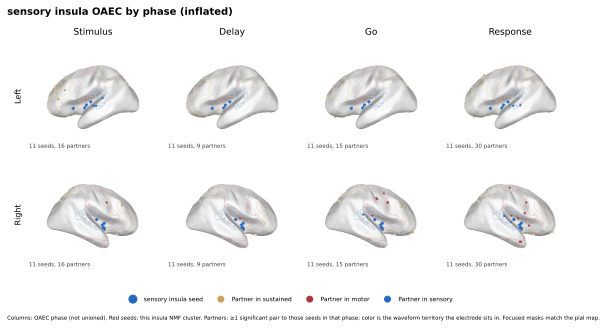

/hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/oaec_sustain_phases_inflated_top50.svg


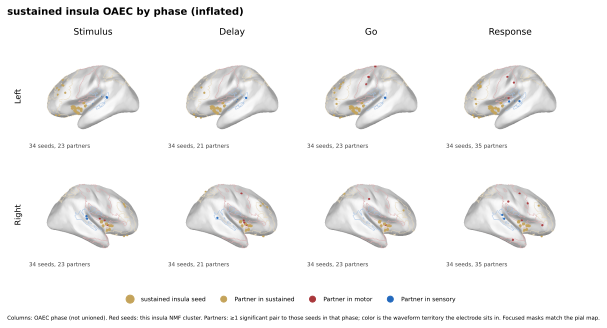

/hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/oaec_motor_phases_inflated_top50.svg


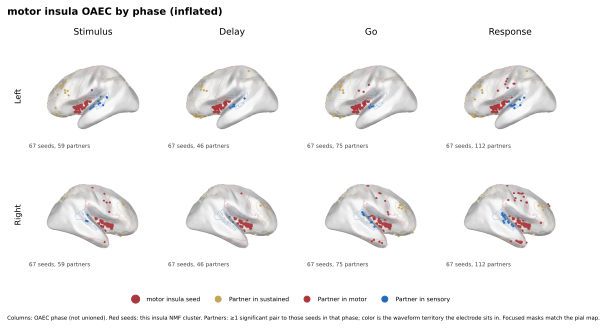

In [16]:
RENDER_CLUSTER_PHASES = False
CLUSTERS = ("sensory", "sustain", "motor")
SURF_PHASES = "inflated"

from IPython.display import SVG, display

if RENDER_CLUSTER_PHASES:
    import importlib
    import pandas as pd

    import src.nmf.oaec_focused_overlay as oaec_focused_overlay

    importlib.reload(oaec_focused_overlay)
    overlay_mod = _load_script(
        "plot_oaec_on_focused_motifs", "scripts/plot_oaec_on_focused_motifs.py"
    )
    nmf_plot = _load_script(
        "plot_nmf_whole_brain_projection",
        "scripts/plot_nmf_whole_brain_projection.py",
    )
    phase_mod = _load_script(
        "plot_oaec_cluster_phases", "scripts/plot_oaec_cluster_phases.py"
    )
    if "thresholds" not in globals() or "value_max" not in globals():
        payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)
        value_max = float(np.asarray(payload["display_value_max"]).reshape(-1)[0])

missing = []
for cluster in CLUSTERS:
    phase_svg = (
        FIG_DIR
        / f"oaec_{cluster}_phases_{SURF_PHASES}_top{int(round(KEEP_TOP * 100))}.svg"
    )
    phase_csv = (
        nmf_wholebrain_dir() / "visualization" / f"oaec_{cluster}_phase_electrodes.csv"
    )
    if RENDER_CLUSTER_PHASES:
        if not phase_csv.exists():
            missing.append(str(phase_csv))
            continue
        table = pd.read_csv(phase_csv)
        frames = phase_mod.frames_from_table(table)
        for phase, frame in frames.items():
            n_seed = int(frame["role"].eq("seed").sum()) if len(frame) else 0
            n_partner = int(frame["role"].eq("partner").sum()) if len(frame) else 0
            print(f"{cluster} {phase}: seeds={n_seed} partners={n_partner}")
        written = phase_mod.plot_cluster_phases(
            overlay_mod=overlay_mod,
            nmf_plot=nmf_plot,
            payload=payload,
            thresholds=thresholds,
            value_max=value_max,
            frames=frames,
            output=phase_svg,
            surf=SURF_PHASES,
            cluster=cluster,
        )
        print(f"Wrote {written}")
        display(SVG(filename=str(written)))
    elif phase_svg.exists():
        print(phase_svg)
        display(SVG(filename=str(phase_svg)))
    else:
        missing.append(str(phase_svg))

if missing:
    print(
        "Waiting for cluster-phase SVGs (job 54058949):\n  "
        + "\n  ".join(missing)
        + "\nRe-run this cell when they appear."
    )


## Insula OAEC: stimulus+delay vs go+response

Two epochs, clusters pooled. A partner is drawn if it has ≥1 significant pair
to any labeled insula seed in that epoch. Point color is the waveform
territory. Background is the filled focused patches. Each epoch is a 2×2
(left/right × lateral/medial).

Submit `scripts/slurm/oaec_pooled_phases.sh` if the SVG is missing.


/hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/whole_brain_projection/oaec_pooled_epochs_inflated_top50.svg


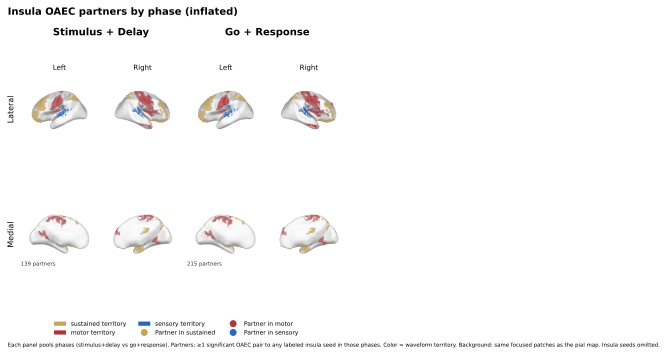

In [21]:
RENDER_POOLED_PHASES = False
SURF_POOLED = "inflated"
POOLED_SVG = (
    FIG_DIR
    / f"oaec_pooled_epochs_{SURF_POOLED}_top{int(round(KEEP_TOP * 100))}.svg"
)
POOLED_CSV = nmf_wholebrain_dir() / "visualization" / "oaec_pooled_epoch_electrodes.csv"

from IPython.display import SVG, display

if RENDER_POOLED_PHASES:
    import importlib
    import pandas as pd

    import src.nmf.oaec_focused_overlay as oaec_focused_overlay

    importlib.reload(oaec_focused_overlay)
    overlay_mod = _load_script(
        "plot_oaec_on_focused_motifs", "scripts/plot_oaec_on_focused_motifs.py"
    )
    nmf_plot = _load_script(
        "plot_nmf_whole_brain_projection",
        "scripts/plot_nmf_whole_brain_projection.py",
    )
    pooled_mod = _load_script(
        "plot_oaec_pooled_phases", "scripts/plot_oaec_pooled_phases.py"
    )
    if not POOLED_CSV.exists():
        raise FileNotFoundError(
            f"{POOLED_CSV} missing. Submit scripts/slurm/oaec_pooled_phases.sh"
        )
    if "thresholds" not in globals() or "value_max" not in globals():
        payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)
        value_max = float(np.asarray(payload["display_value_max"]).reshape(-1)[0])
    table = pd.read_csv(POOLED_CSV)
    frames = pooled_mod.frames_from_table(table, pooled_mod.EPOCH_ORDER)
    for phase, frame in frames.items():
        print(f"{phase}: partners={len(frame)}")
    written = pooled_mod.plot_pooled_phases(
        overlay_mod=overlay_mod,
        nmf_plot=nmf_plot,
        payload=payload,
        thresholds=thresholds,
        value_max=value_max,
        frames=frames,
        output=POOLED_SVG,
        surf=SURF_POOLED,
        phase_order=pooled_mod.EPOCH_ORDER,
    )
    print(f"Wrote {written}")
    display(SVG(filename=str(written)))
elif POOLED_SVG.exists():
    print(POOLED_SVG)
    display(SVG(filename=str(POOLED_SVG)))
else:
    print(
        "Pooled epoch SVG not found. Submit scripts/slurm/oaec_pooled_phases.sh "
        "then re-run this cell."
    )
